In [1]:
import seaborn as sns
import pandas as pd
import plotly.express as px

In [3]:
df = sns.load_dataset("iris")

In [7]:
df_ = df.copy()
df_["species_numerical"] = df_["species"].map(
    {"setosa":0,"versicolor":1,"virginica":2})

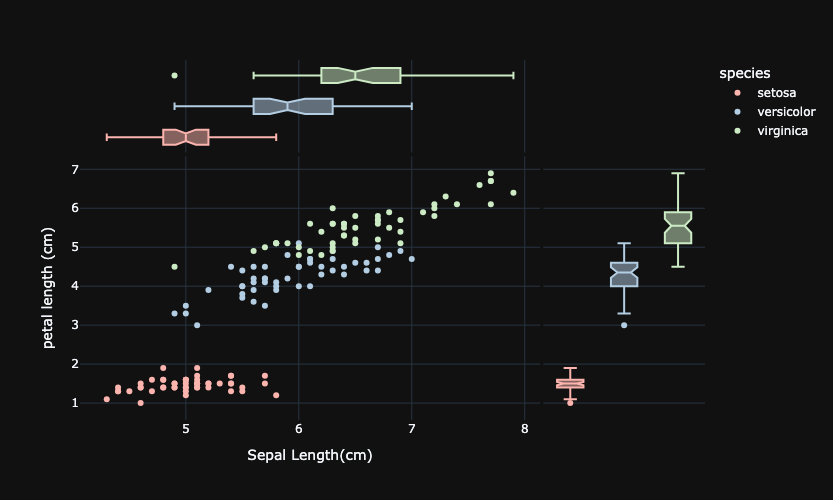

In [21]:
fig = px.scatter(df, x = 'sepal_length',y = 'petal_length', #导入数据,并指定两个轴的数据(关键字参数)
                 color = 'species',#根据关键字列指定不同的颜色,这里这列表示种类,按照种类绘制
                 marginal_x = 'box', marginal_y = 'box',#在边缘添加箱型图
                 template = "plotly_dark", #配置背景显示风格
                 width = 600,height = 500, #尺寸单位为像素
                 color_discrete_sequence = px.colors.qualitative.Pastel1, #颜色映射调色板
                 labels = {"sepal_length":"Sepal Length(cm)",
                           "petal_length":"petal length (cm)"})
fig.show()

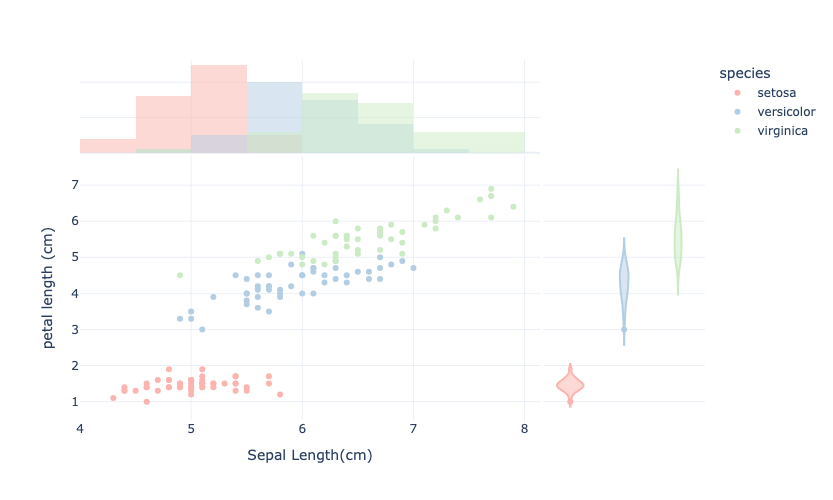

In [17]:
fig = px.scatter(df, x = 'sepal_length',y = 'petal_length', #导入数据,并指定两个轴的数据(关键字参数)
                 color = 'species',#根据关键字列指定不同的颜色,这里这列表示种类,按照种类绘制
                 marginal_x = 'histogram', marginal_y = 'violin',#在边缘添加箱型图
                 template = "plotly_white", #
                 width = 600,height = 500,
                 color_discrete_sequence = px.colors.qualitative.Pastel1,
                 labels = {"sepal_length":"Sepal Length(cm)",
                           "petal_length":"petal length (cm)"})
fig.show()

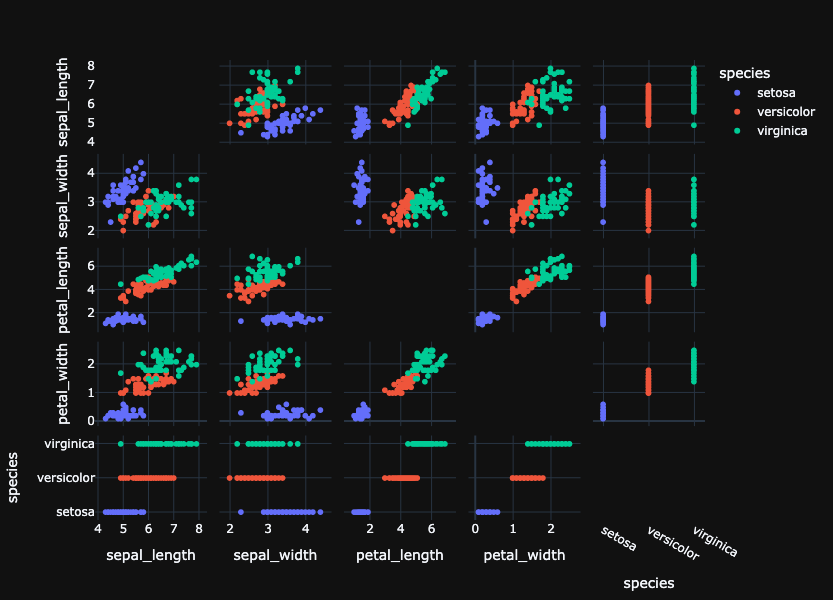

In [25]:
fig = px.scatter_matrix(df,
                        dimensions=["sepal_length","sepal_width",
                                    "petal_length","petal_width",
                                    "species"],
                        template = "plotly_dark",
                        color = 'species',width=600,height=600)
#对角线配置为不可见
fig.update_traces(diagonal_visible=False)
fig.show()

In [27]:
df['area'] = df['sepal_length'] * df['sepal_width']  #结果保存在数据帧新的列
#按照面结进行分类,将分类结果A-E分配到新的列
df['Category'] = pd.qcut(df['area'], 5,labels = ['A','B','C','D','E'])

In [39]:
import numpy as np
list_stats = ['min','max','mean','median','std'] #定义一个列表,包含这些名称
#先根据category分组,然后根据分组后的标签area计算,agg计算上个list_stats中列出的统计量
stats_by_area = df.groupby('Category')['area'].agg(list_stats)

stats_by_area['Range'] = stats_by_area['max'] - stats_by_area['min']
#方法df.value_counts默认返回降序 ,当赋值时候,会按照原列表的索引对其
stats_by_area['Number'] = df['Category'].value_counts()

/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_88868/1563371963.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [41]:
stats_by_area

,min,max,mean,median,std,Range,Number
Category,,,,,,,
A,10.00,15.00,13.421667,13.695,1.278288,5.00,30
B,15.04,16.80,15.912000,15.910,0.540532,1.76,30
C,16.83,18.30,17.623226,17.680,0.436023,1.47,31
D,18.36,20.77,19.701379,19.610,0.728044,2.41,29
E,20.79,30.02,22.525333,21.630,2.274115,9.23,30


In [37]:
stats_by_area.to_csv('stats_by_area.csv')

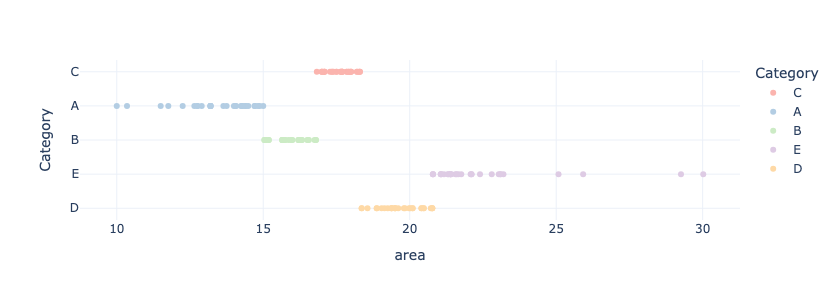

In [46]:
fig = px.scatter(df,x='area',y='Category',
                 color = 'Category',
                 template = 'plotly_white',
                 width=600,height=300,
                 color_discrete_sequence=px.colors.qualitative.Pastel1)
fig.show()

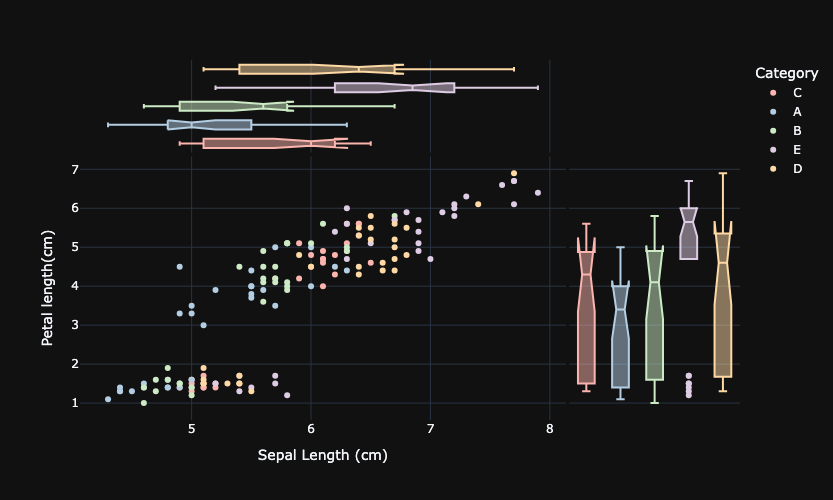

In [56]:
fig = px.scatter(df,x='sepal_length',y='petal_length',
                 color = 'Category',marginal_x='box',
                 marginal_y = 'box',template = 'plotly_dark',
                 width=600,height=500,
                 color_discrete_sequence=px.colors.qualitative.Pastel1,
                 labels={'sepal_length':'Sepal Length (cm)',
                         'petal_length':'Petal length(cm)'})
fig.show()

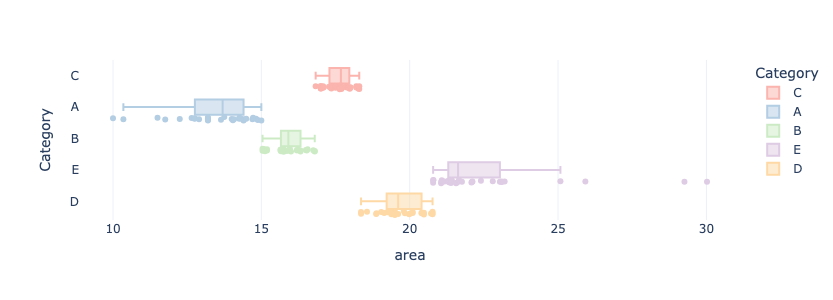

In [58]:
fig = px.box(df,x='area',y='Category',
             color = 'Category',points='all',
             template = 'plotly_white',
             width=600,height=300,
             color_discrete_sequence = px.colors.qualitative.Pastel1)
fig.show()

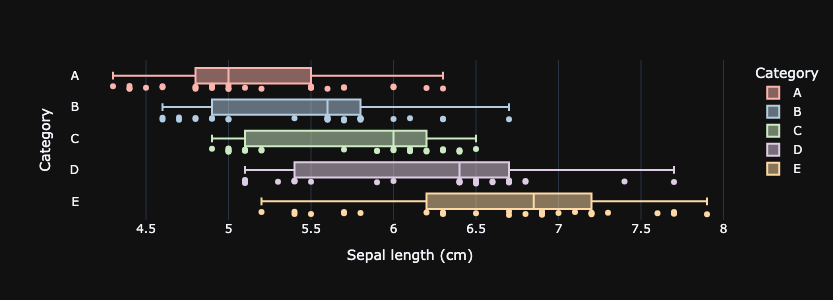

In [62]:
fig = px.box(df,x = 'sepal_length',y = 'Category',
             color = 'Category',points='all',
             template = 'plotly_dark',
             width=600,height=300,
             #orders表示顺序,plotly自动查找数值是否在此变量汇总被排序
             category_orders={'Category':['A','B','C','D','E']},
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             labels={'sepal_length':'Sepal length (cm)'})
fig.show()

In [64]:
freq_matrix = pd.crosstab(index = df['Category'],
                          columns = df['species'])

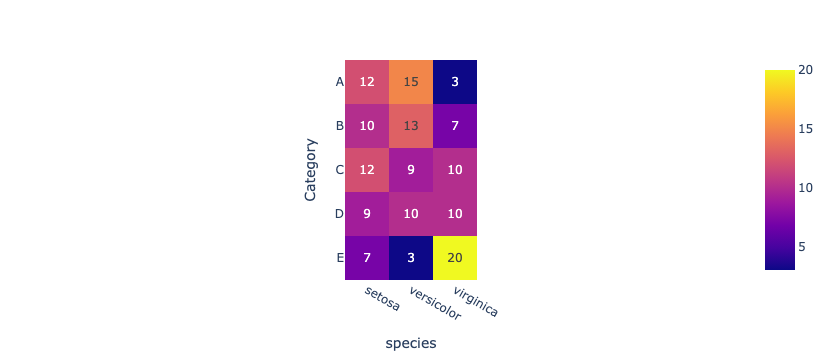

In [78]:
fig = px.imshow(freq_matrix,text_auto=True)
fig.show()

In [84]:
freq_matrix.sum(axis=1)

Category
A    30
B    30
C    31
D    29
E    30
dtype: int64

In [74]:
prob_matrix = pd.crosstab(index = df['Category'],
                           columns = df['species'],
                           normalize = 'all')#限制为二维频数

In [76]:
prob_matrix

species,setosa,versicolor,virginica
Category,,,
A,0.080000,0.100000,0.020000
B,0.066667,0.086667,0.046667
C,0.080000,0.060000,0.066667
D,0.060000,0.066667,0.066667
E,0.046667,0.020000,0.133333


In [86]:
df['Category'].value_counts().sort_index()

Category
A    30
B    30
C    31
D    29
E    30
Name: count, dtype: int64

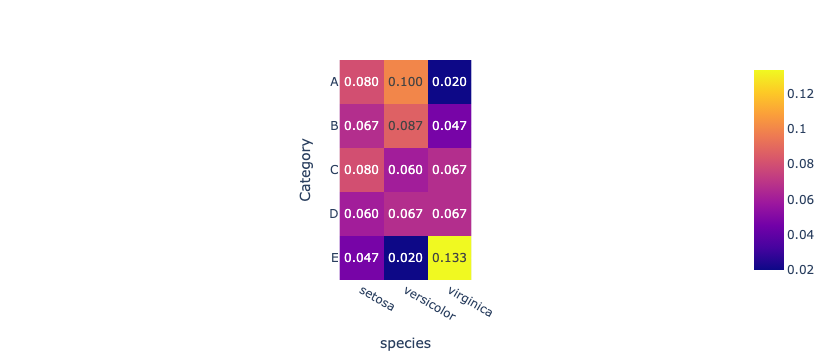

In [98]:
fig = px.imshow(prob_matrix,text_auto = '.3f')
fig.show()

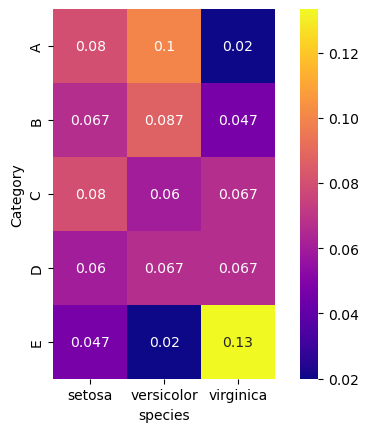

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(prob_matrix,cmap = 'plasma',square = True,annot = True)
plt.savefig('heatmap.svg')

In [102]:
prob_matrix

species,setosa,versicolor,virginica
Category,,,
A,0.080000,0.100000,0.020000
B,0.066667,0.086667,0.046667
C,0.080000,0.060000,0.066667
D,0.060000,0.066667,0.066667
E,0.046667,0.020000,0.133333


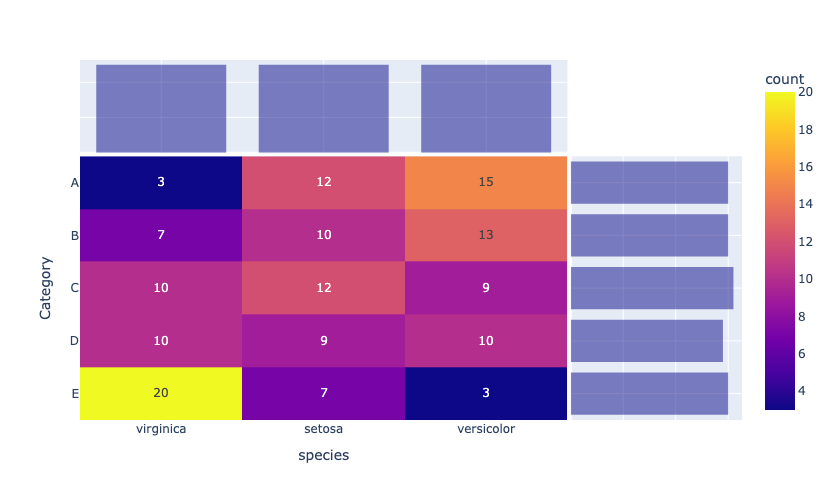

In [126]:
fig = px.density_heatmap(df,x = 'species',y = 'Category',
                         category_orders = {'Category':['A','B','C','D','E'],
                                            'species':['virginica','setosa','versicolor']},
                         marginal_x='histogram',marginal_y='histogram',
                         text_auto=True,width=400,height=500)
fig.show()

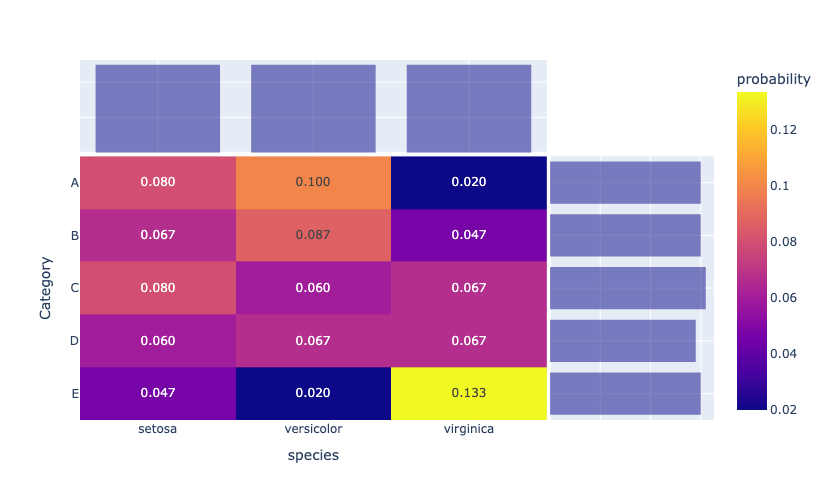

In [116]:
fig = px.density_heatmap(df,x='species',y='Category',
                         category_orders={'Category':['A','B','C','D','E']},
                         marginal_x='histogram',marginal_y='histogram',
                         #设置为热图的概率密度,虽然是矩阵,但是就是用这个函数做数据统计,是2D直方图
                         histnorm = 'probability',
                         text_auto = '.3f',width=400,height=500)
fig.show()

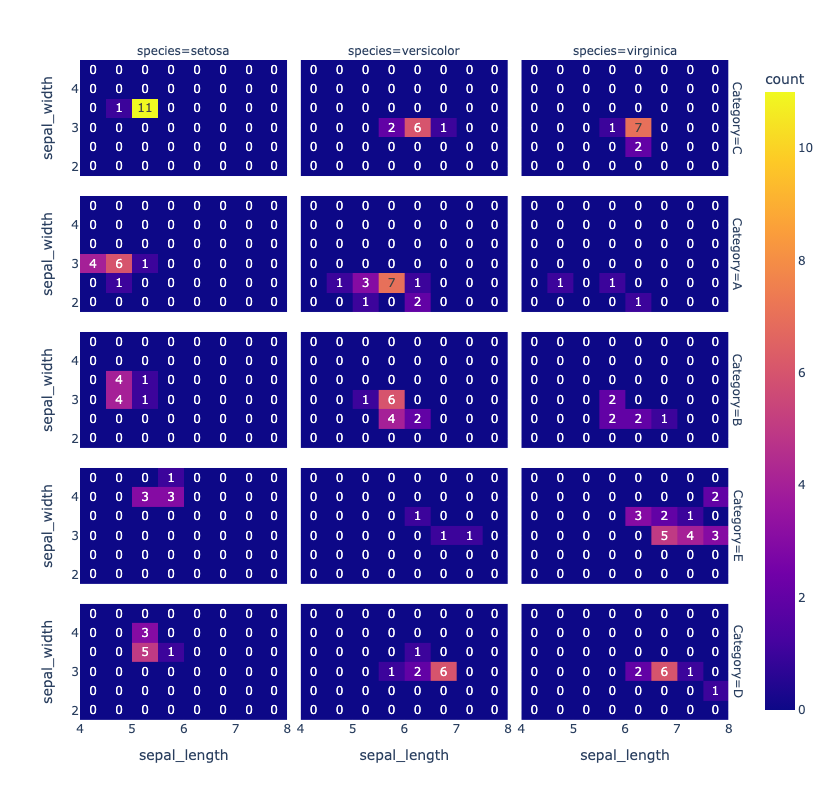

In [132]:
fig = px.density_heatmap(df,
                         #子图的热图中的x,y轴的变量
                         x='sepal_length',y='sepal_width',
                         #子图的变量,根据变量格式自动分配形状
                         facet_row='Category',facet_col='species',
                         width=500,height=800,text_auto=True)
fig.show()

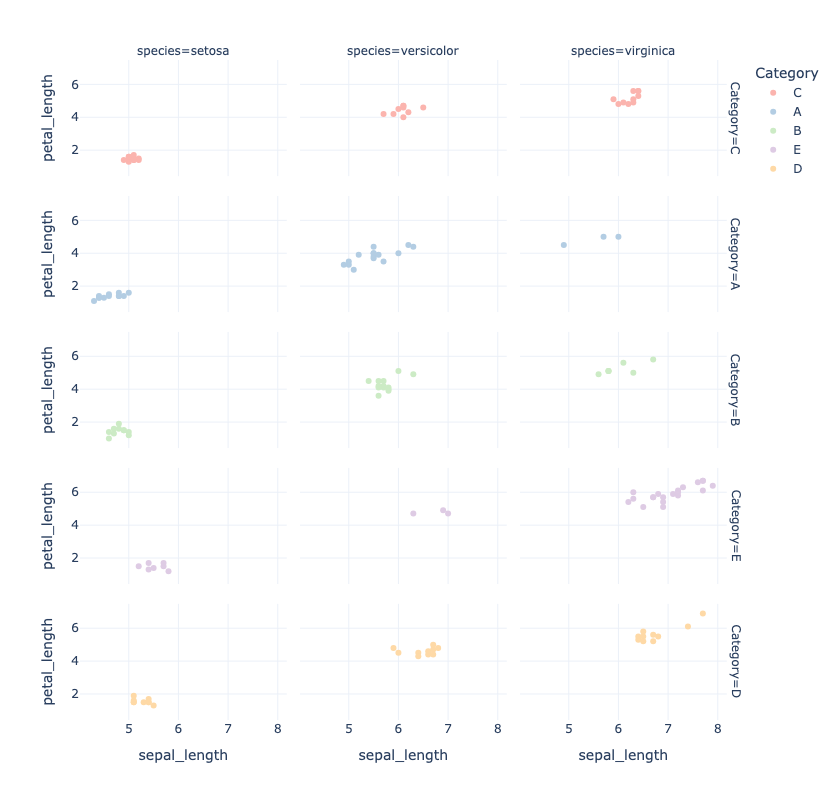

In [138]:
fig = px.scatter(df,
                 x='sepal_length',y='petal_length',
                 template = 'plotly_white',
                 color_discrete_sequence=px.colors.qualitative.Pastel1,
                 width=700,height=800,
                 color='Category',facet_col='species',
                 facet_row='Category')
fig.show()

In [158]:
#归一化计算概率,如果为False表示计算频数,Series格式的索引为Category
ctg_percent = df['Category'].value_counts(normalize=True)
#将pandas series抓为df格式,有两列
ctg_percent = pd.DataFrame({'Category':ctg_percent.index,#使用索引表示新的列数据
                            'Ratio':ctg_percent.values})

ctg_percent

,Category,Ratio
0,C,0.206667
1,A,0.200000
2,B,0.200000
3,E,0.200000
4,D,0.193333


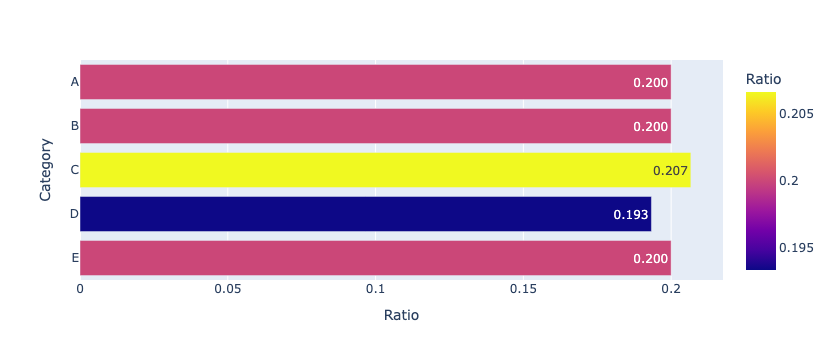

In [154]:
fig = px.bar(ctg_percent,
             x='Ratio',y='Category',
             category_orders={'Category':['A','B','C','D','E']},
             color = 'Ratio',orientation = 'h',
             text_auto = '.3f')

fig.show()

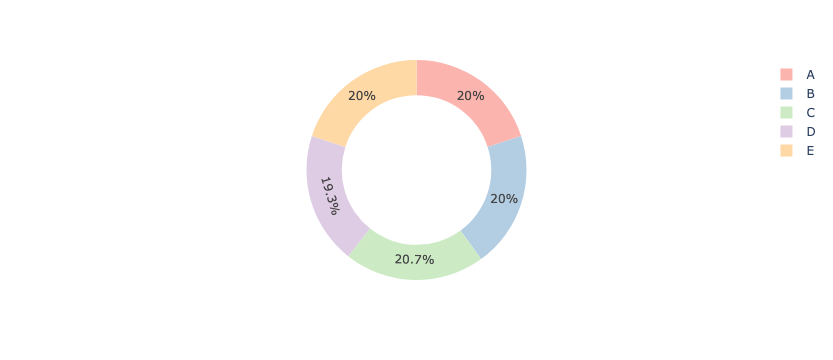

In [150]:
fig = px.pie(ctg_percent,
             category_orders={'Category':['A','B','C','D','E']},
             color_discrete_sequence = px.colors.qualitative.Pastel1,
             #指定为环形数据来源
             values='Ratio',names='Category')
#将68%区域挖空,变成环形图
fig.update_traces(hole=.68)
fig.show()


In [160]:
species_percent = df['species'].value_counts(normalize=True)
species_percent = pd.DataFrame({'species':species_percent.index,
                                'Ratio':species_percent.values})
species_percent

,species,Ratio
0,setosa,0.333333
1,versicolor,0.333333
2,virginica,0.333333


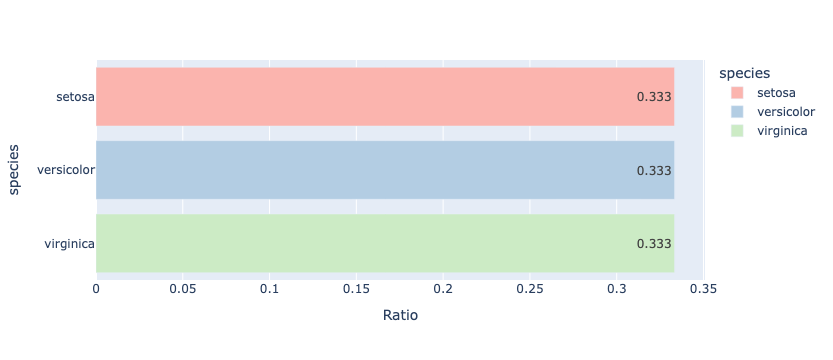

In [162]:
fig = px.bar(species_percent,
             x='Ratio',y='species',
             category_orders = {'species':['setosa','versicolor','virginica']},
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             color = 'species',orientation='h',
             text_auto = '.3f')

fig.show()

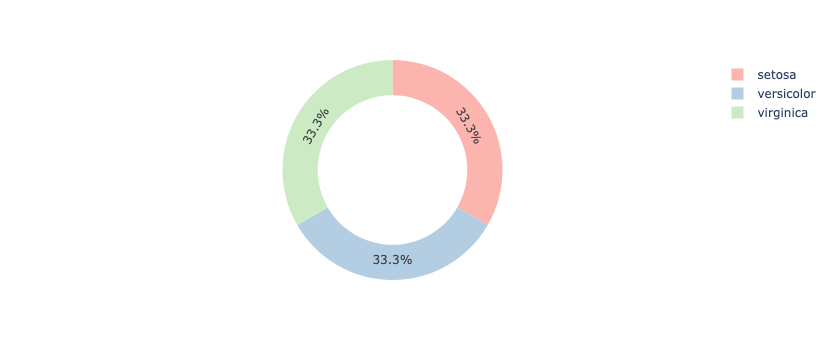

In [172]:
fig = px.pie(species_percent,
             category_orders={'species':['setosa','versicolor','virginica']},
             color_discrete_sequence = px.colors.qualitative.Pastel1,
             #names的作用给定扇区分类标签,为了扇区标签(交互显示名称),显示图例
             values='Ratio',names='species')

fig.update_traces(hole=.68)
fig.show()

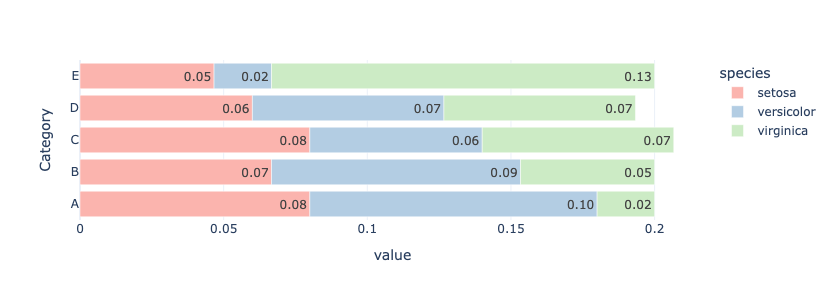

In [180]:
fig = px.bar(prob_matrix,
             template = 'plotly_white',orientation = 'h',
             color_discrete_sequence = px.colors.qualitative.Pastel1,
             width=600,height=300,text_auto='.2f')
fig.show()

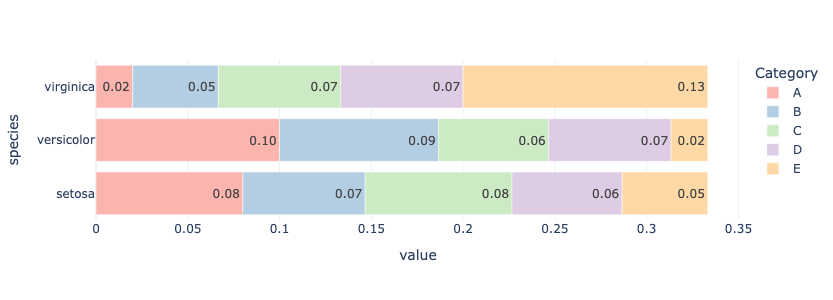

In [184]:
fig = px.bar(prob_matrix.T,
             template = 'plotly_white',orientation = 'h',
             color_discrete_sequence = px.colors.qualitative.Pastel1,
             width=600,height=300,text_auto='.2f')
fig.show()

In [226]:
ratio_species_in_category = pd.crosstab(index = df['Category'],
                                        columns = df['species'],
                                        normalize = 'index')

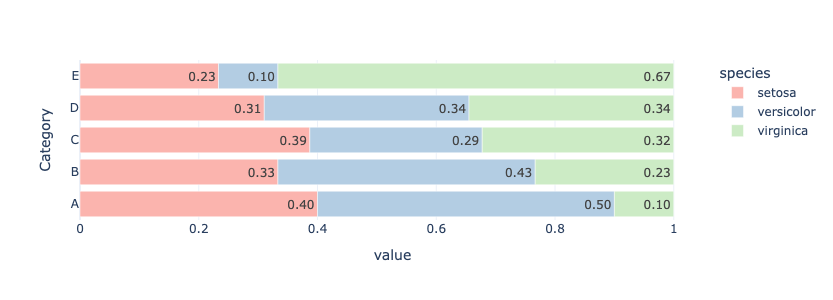

In [228]:
fig = px.bar(ratio_species_in_category,
             template = 'plotly_white',orientation = 'h',
             color_discrete_sequence = px.colors.qualitative.Pastel1,
             width = 600 , height = 300 , text_auto = '.2f')
fig.show()

In [198]:
ratio_category_in_species = pd.crosstab(index = df['species'],
                                        columns = df['Category'],
                                        normalize = 'index')

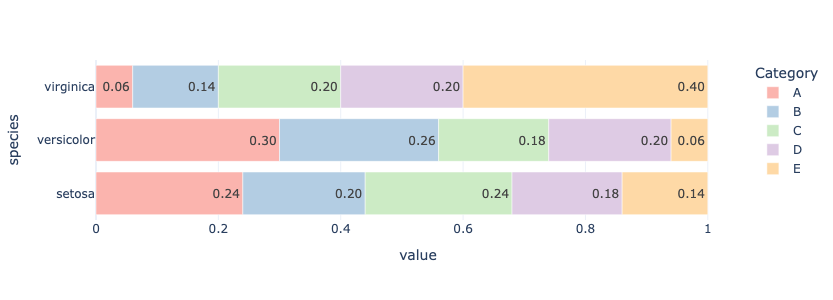

In [200]:
fig = px.bar(ratio_category_in_species,
             template = 'plotly_white',orientation = 'h',
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             width=600,height=300,text_auto = '.2f')

fig.show()

In [230]:
prob_matrix_stacked=prob_matrix.stack().reset_index().rename(
    columns={0:'Ratio'})
prob_matrix_stacked

,Category,species,Ratio
0,A,setosa,0.080000
1,A,versicolor,0.100000
2,A,virginica,0.020000
3,B,setosa,0.066667
4,B,versicolor,0.086667
5,B,virginica,0.046667
6,C,setosa,0.080000
7,C,versicolor,0.060000
8,C,virginica,0.066667
9,D,setosa,0.060000


In [232]:
prob_matrix_stacked.to_csv('prob_matrix_stacked.csv')

/opt/anaconda3/lib/python3.12/site-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



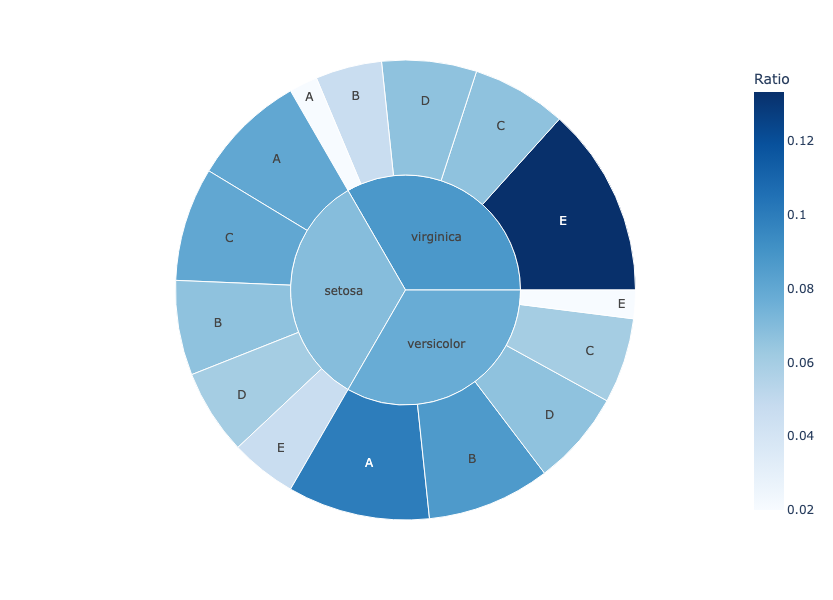

In [246]:
fig = px.sunburst(prob_matrix_stacked,
                  path=['species','Category'],
                  values='Ratio',color='Ratio',
                  color_continuous_scale=px.colors.sequential.Blues,  # 或其他连续色带
                  width=600,height=600)
fig.show()

/opt/anaconda3/lib/python3.12/site-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/opt/anaconda3/lib/python3.12/site-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



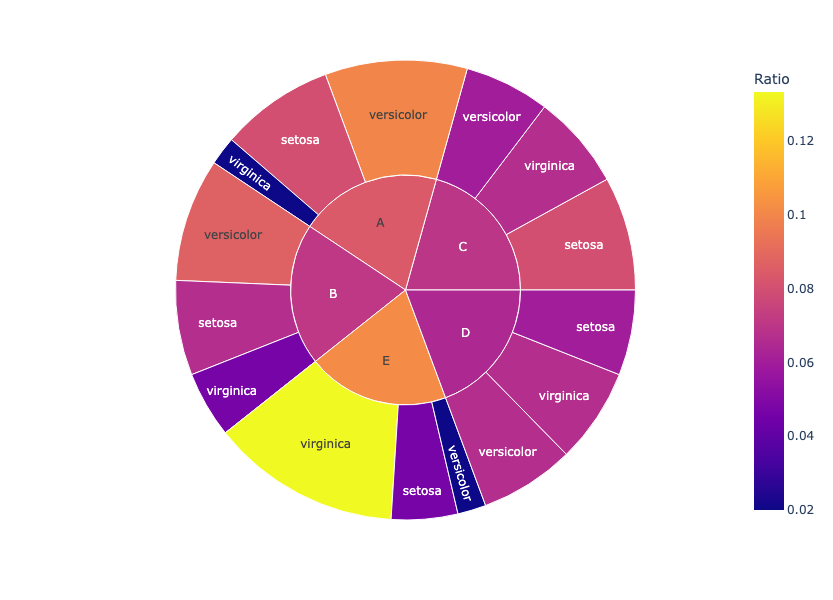

In [236]:
fig = px.sunburst(prob_matrix_stacked,
                  path=['Category','species'],
                  values='Ratio',color='Ratio',
                  width=600,height=600)
fig.show()

In [248]:
labels = ["{0} - {1} cm".format(i,i+1) for i in range(4,8)]#配置标签
df["sepal_length_bins"] = pd.cut(df.sepal_length,range(4,9),#按照范围进行数据划分
                                 right = False,labels=labels)

In [258]:
sepal_length_bins_counts = df['sepal_length_bins'].value_counts()#统计每种样本的个数,这里行索引标签为之前配置的标签,列索引为添加的列名
sepal_length_bins_counts = pd.DataFrame({
    'sepal_length_bins':sepal_length_bins_counts.index,#配置新的列标签是两个,一列为之前的索引名,一个为之前的值
    'Count':sepal_length_bins_counts.values})

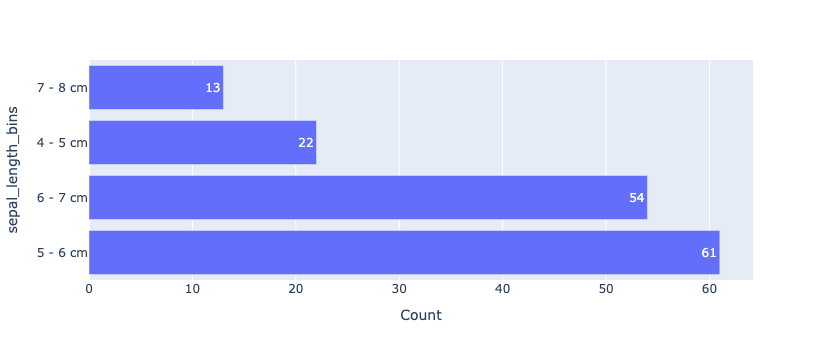

In [262]:
fig = px.bar(sepal_length_bins_counts,
             x='Count',y='sepal_length_bins',
             orientation = 'h',text_auto = True)
fig.show()

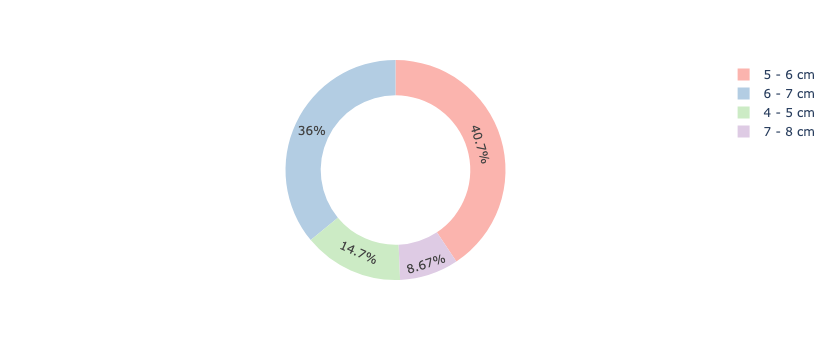

In [266]:
fig = px.pie(sepal_length_bins_counts,
             color_discrete_sequence = px.colors.qualitative.Pastel1,
             values='Count',names='sepal_length_bins')
fig.update_traces(hole=.68)
fig.show()

In [274]:
df.sepal_length.mean()

5.843333333333334

In [302]:
dims = ['sepal_length_bins','species','Category']

prob_matrix_by_3 = df.groupby(dims)['sepal_length'].apply(lambda x:x.count()/len(df))
prob_matrix_by_3

/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_88868/85441847.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



sepal_length_bins  species     Category
4 - 5 cm           setosa      A           0.073333
                               B           0.053333
                               C           0.006667
                               D                NaN
                               E                NaN
                   versicolor  A           0.006667
                               B                NaN
                               C                NaN
                               D                NaN
                               E                NaN
                   virginica   A           0.006667
                               B                NaN
                               C                NaN
                               D                NaN
                               E                NaN
5 - 6 cm           setosa      A           0.006667
                               B           0.013333
                               C           0.073333
                        

In [304]:
prob_matrix_by_3 = prob_matrix_by_3.reset_index()
prob_matrix_by_3

,sepal_length_bins,species,Category,sepal_length
0,4 - 5 cm,setosa,A,0.073333
1,4 - 5 cm,setosa,B,0.053333
2,4 - 5 cm,setosa,C,0.006667
3,4 - 5 cm,setosa,D,NaN
4,4 - 5 cm,setosa,E,NaN
5,4 - 5 cm,versicolor,A,0.006667
6,4 - 5 cm,versicolor,B,NaN
7,4 - 5 cm,versicolor,C,NaN
8,4 - 5 cm,versicolor,D,NaN
9,4 - 5 cm,versicolor,E,NaN


In [306]:
prob_matrix_by_3.rename(columns = {'sepal_length':'Ratio'},
                        inplace = True)
prob_matrix_by_3

,sepal_length_bins,species,Category,Ratio
0,4 - 5 cm,setosa,A,0.073333
1,4 - 5 cm,setosa,B,0.053333
2,4 - 5 cm,setosa,C,0.006667
3,4 - 5 cm,setosa,D,NaN
4,4 - 5 cm,setosa,E,NaN
5,4 - 5 cm,versicolor,A,0.006667
6,4 - 5 cm,versicolor,B,NaN
7,4 - 5 cm,versicolor,C,NaN
8,4 - 5 cm,versicolor,D,NaN
9,4 - 5 cm,versicolor,E,NaN


/opt/anaconda3/lib/python3.12/site-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/opt/anaconda3/lib/python3.12/site-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/opt/anaconda3/lib/python3.12/site-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



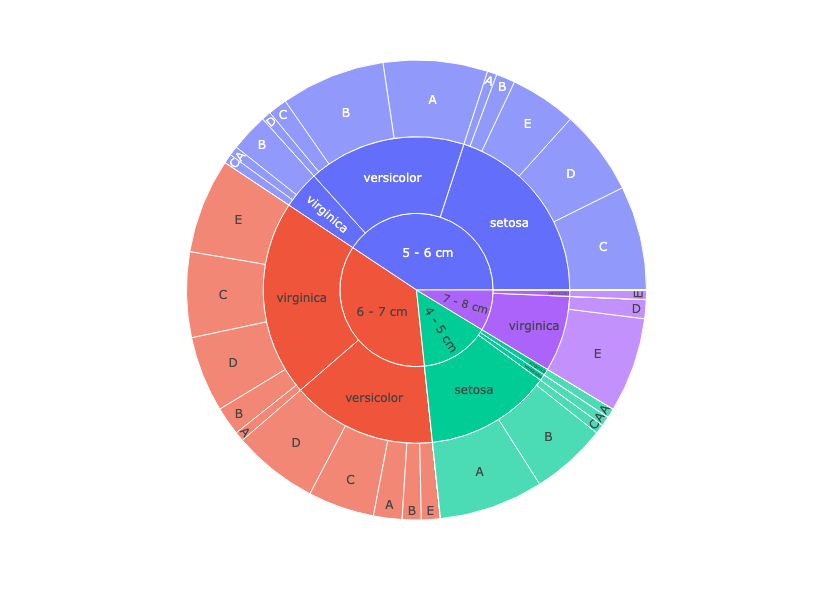

In [308]:
fig = px.sunburst(prob_matrix_by_3,
                  path = dims,
                  values='Ratio',
                  width = 600,height=600)
fig.show()

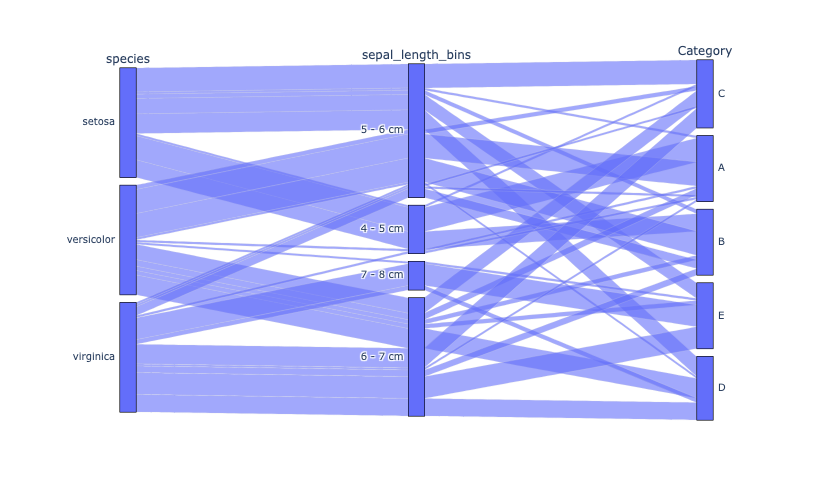

In [310]:
dim_2=['species','sepal_length_bins','Category']
fig = px.parallel_categories(df,
                             dimensions = dim_2,
                             width = 800,height = 500)
fig.show()

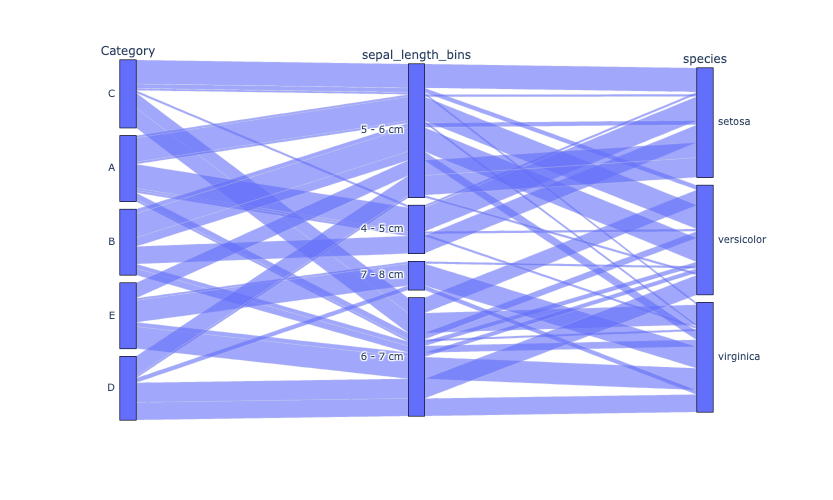

In [312]:
dim_3=['Category','sepal_length_bins','species']
fig = px.parallel_categories(df,
                             dimensions = dim_3,
                             width = 800,height = 500
fig.show()
